In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset (Requirement: Analyze dataset)
data = pd.read_csv("framingham.csv")
print(data.shape)


(4238, 16)


In [12]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [14]:
# Check Missing Values (Requirement: handle missing values)
print(data.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [15]:
# Handle Missing Values
# Fill each column's missing values with its median
# (median is used instead of mean because it's less affected by outliers,
#  which is common in medical data like cholesterol, glucose, etc.)
for col in data.columns[data.isnull().sum() > 0]:
    data[col] = data[col].fillna(data[col].median())


In [16]:
data.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [ ]:
# Encoding Check (Requirement: if needed)
print(data.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


In [18]:
# Section 6: Check Imbalance
print(data['TenYearCHD'].value_counts())

TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [19]:
# Features and Target
X = data.drop(columns=['TenYearCHD'])
y = data['TenYearCHD']

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Feature Scaling (Requirement: apply if required)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Section 10: Balance Dataset (Requirement: since imbalanced)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

After SMOTE: {0: 2875, 1: 2875}


In [23]:
# Train Different Models and Compare

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)


                              
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.663915,0.248387,0.596899,0.350797
1,Decision Tree,0.725236,0.214286,0.302326,0.250804
2,Random Forest,0.791274,0.239130,0.170543,0.199095



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



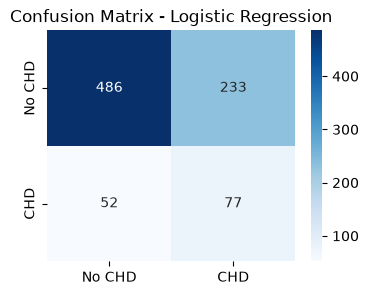


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       719
           1       0.21      0.30      0.25       129

    accuracy                           0.73       848
   macro avg       0.54      0.55      0.54       848
weighted avg       0.77      0.73      0.74       848



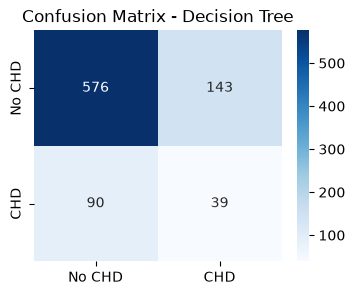


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       719
           1       0.24      0.17      0.20       129

    accuracy                           0.79       848
   macro avg       0.55      0.54      0.54       848
weighted avg       0.76      0.79      0.78       848



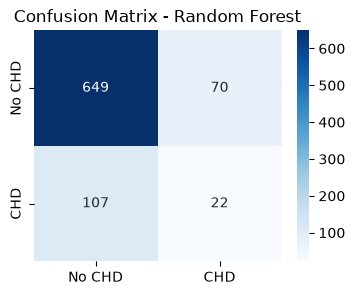

In [24]:
# Classification Report + Confusion Matrix (Required for each model)
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [25]:
# Select Best Model
best_model_name = results_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
print("Best model:", best_model_name)

Best model: Logistic Regression


In [26]:
# Hyperparameter Tuning (Requirement: improve performance)
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_balanced, y_train_balanced)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 0.01}


Accuracy:  0.6580188679245284
Precision: 0.24444444444444444
Recall:    0.5968992248062015
F1-Score:  0.34684684684684686

               precision    recall  f1-score   support

           0       0.90      0.67      0.77       719
           1       0.24      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.70       848



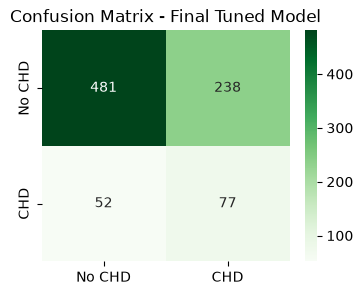

In [27]:
# Final Tuned Model Evaluation
best_model = grid_search.best_estimator_
final_preds = best_model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))
print("Recall:   ", recall_score(y_test, final_preds))
print("F1-Score: ", f1_score(y_test, final_preds))
print("\n", classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.title("Confusion Matrix - Final Tuned Model")
plt.show()